PART A: ANN FOR REGRESSION (California Housing Dataset)

In [1]:
# Student Identifier
STUDENT_ROLL_NO = "24BAD047" 
print(f"Part A - Student Roll No: {STUDENT_ROLL_NO}\n" + "="*50)

Part A - Student Roll No: 24BAD047


In [21]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [22]:
# 2. Load Dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [23]:
# 3. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# 4. Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# 5. Build ANN Model Architecture
model_reg = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),  # Explicit Input layer
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Linear output for regression
])

In [26]:
# 6. Compile Model
model_reg.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [27]:
# 7. Train Model
history = model_reg.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 1.0795 - mae: 0.6837 - val_loss: 0.5138 - val_mae: 0.5066
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4251 - mae: 0.4650 - val_loss: 0.4162 - val_mae: 0.4538
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3771 - mae: 0.4374 - val_loss: 0.3947 - val_mae: 0.4508
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3658 - mae: 0.4294 - val_loss: 0.3897 - val_mae: 0.4418
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3560 - mae: 0.4206 - val_loss: 0.3781 - val_mae: 0.4242
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3423 - mae: 0.4146 - val_loss: 0.3606 - val_mae: 0.4251
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3320 - mae: 0.4070 - val_loss: 0.3603 - val_mae: 0.4258
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3266 - mae: 0.4030 - val_loss: 0.3940 - val_mae: 0.4450
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - 

In [28]:
# 8. Predictions & Evaluation
y_pred = model_reg.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [29]:
print("\n" + "="*30)
print(f"REGRESSION EVALUATION RESULTS ({STUDENT_ROLL_NO})")
print("="*30)
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root MSE (RMSE)          : {rmse:.4f}")


REGRESSION EVALUATION RESULTS (24BAD047)
Mean Squared Error (MSE) : 0.2978
Mean Absolute Error (MAE): 0.3775
Root MSE (RMSE)          : 0.5458


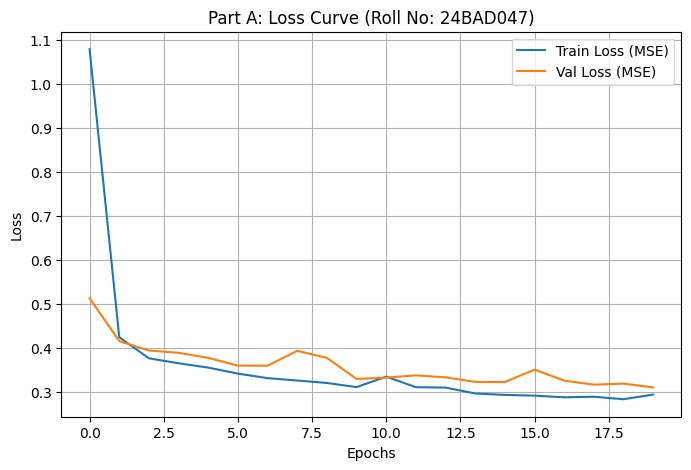

In [30]:
# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title(f'Part A: Loss Curve (Roll No: {STUDENT_ROLL_NO})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()